# Notebook5- Models & Data
**ECE 5424 Advanced ML Capstone** | Virginia Tech Spring 2026

Builds all three model architectures and replaces the time surface placeholder with real event data.

**Steps:**
1. Real time surface construction (standalone test)
2. Update `DSECFusionDataset` + train/val split
3. Define all three model architectures
4. Forward-pass verification + parameter counts

## 1.Real Time Surface Construction

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import hdf5plugin          # MUST come before h5py (BLOSC compression)
import h5py
import numpy as np
import json
from config import DATA_ROOT

DATA_ROOT = Path(DATA_ROOT)
SEQUENCE  = "zurich_city_04_a"
SEQ_DIR   = DATA_ROOT / SEQUENCE

# Load events once — arrays stay in RAM for fast per-sample binary search
events_path = SEQ_DIR / f"{SEQUENCE}_events_left" / "events.h5"

with h5py.File(events_path, 'r') as f:
    print("events.h5 structure:")
    f.visititems(lambda name, obj: print(f"  {name}"))
    t_offset = int(f['t_offset'][()])
    print(f"\nt_offset: {t_offset} µs")
    t_all = f['events']['t'][:]
    x_all = f['events']['x'][:]
    y_all = f['events']['y'][:]
    p_all = f['events']['p'][:]

# Absolute timestamps in µs
t_abs = t_all.astype(np.int64) + t_offset
print(f"Event absolute time range: {t_abs[0]} to {t_abs[-1]} µs")
print(f"Total events: {len(t_abs):,}")


events.h5 structure:
  events
  events/p
  events/t
  events/x
  events/y
  ms_to_idx
  t_offset

t_offset: 36470599656 µs
Event absolute time range: 36470599656 to 36505601655 µs
Total events: 358,941,868


In [2]:
from src.datasets.dsec_dataset import build_time_surface

# Test on the first pair
with open(REPO_ROOT / "data" / "zurich_city_04_a_pairs.json") as f:
    pairs = json.load(f)

pair = pairs[0]
ts = build_time_surface(t_abs, x_all, y_all, p_all, pair['frame_ts'])

print(f"Time surface shape : {ts.shape}")
print(f"ON  channel active pixels : {(ts[0] > 0).sum()}")
print(f"OFF channel active pixels : {(ts[1] > 0).sum()}")
print(f"ON  sparsity : {(ts[0] > 0).sum() / (480*640) * 100:.1f}%")
print(f"OFF sparsity : {(ts[1] > 0).sum() / (480*640) * 100:.1f}%")


Time surface shape : (2, 480, 640)
ON  channel active pixels : 2159
OFF channel active pixels : 1769
ON  sparsity : 0.7%
OFF sparsity : 0.6%


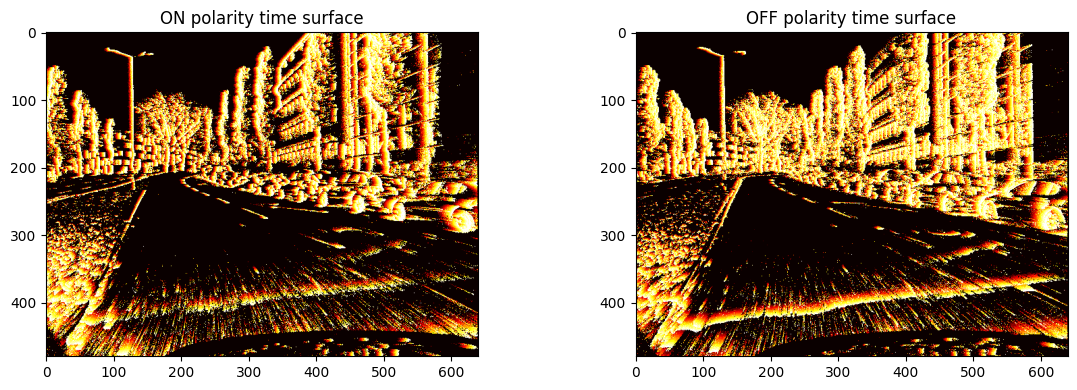

Saved to docs\figures\time_surface_real.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(ts[0], cmap='hot')
axes[0].set_title("ON polarity time surface")
axes[1].imshow(ts[1], cmap='hot')
axes[1].set_title("OFF polarity time surface")
plt.tight_layout()

fig_path = REPO_ROOT / "docs" / "figures" / "time_surface_real.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved to {fig_path.relative_to(REPO_ROOT)}")


In [5]:
#0.7/0.6% sparsity is much lower than 30% expected.

# Check sparsity across a spread of frames to see if frame 0 is representative
check_frames = [0, 50, 100, 175, 250, 349]
print(f"{'frame':>6}  {'ON %':>6}  {'OFF %':>6}  {'ON px':>6}  {'OFF px':>6}")
for i in check_frames:
    ts_check = build_time_surface(t_abs, x_all, y_all, p_all, pairs[i]['frame_ts'])
    on_pct  = (ts_check[0] > 0).sum() / (480*640) * 100
    off_pct = (ts_check[1] > 0).sum() / (480*640) * 100
    print(f"{i:>6}  {on_pct:>6.1f}  {off_pct:>6.1f}  {int((ts_check[0]>0).sum()):>6}  {int((ts_check[1]>0).sum()):>6}")

 frame    ON %   OFF %   ON px  OFF px
     0     0.7     0.6    2159    1769
    50    40.0    44.7  122817  137428
   100    29.9    32.9   91715  101150
   175    30.3    33.8   93148  103837
   250    13.1    12.6   40369   38745
   349    16.4    17.9   50359   54878


In [6]:
# Test on the 50 pair
with open(REPO_ROOT / "data" / "zurich_city_04_a_pairs.json") as f:
    pairs = json.load(f)

pair = pairs[50]
ts = build_time_surface(t_abs, x_all, y_all, p_all, pair['frame_ts'])

print(f"Time surface shape : {ts.shape}")
print(f"ON  channel active pixels : {(ts[0] > 0).sum()}")
print(f"OFF channel active pixels : {(ts[1] > 0).sum()}")
print(f"ON  sparsity : {(ts[0] > 0).sum() / (480*640) * 100:.1f}%")
print(f"OFF sparsity : {(ts[1] > 0).sum() / (480*640) * 100:.1f}%")

Time surface shape : (2, 480, 640)
ON  channel active pixels : 122817
OFF channel active pixels : 137428
ON  sparsity : 40.0%
OFF sparsity : 44.7%


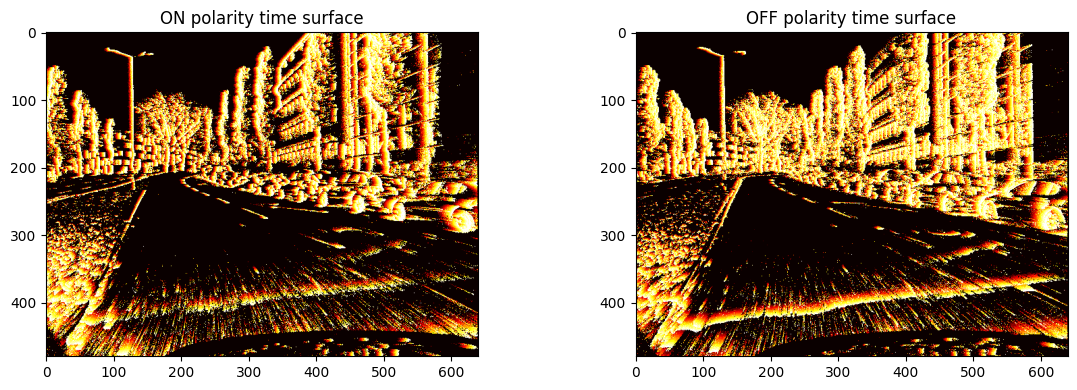

Saved to docs\figures\time_surface_real2.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(ts[0], cmap='hot')
axes[0].set_title("ON polarity time surface")
axes[1].imshow(ts[1], cmap='hot')
axes[1].set_title("OFF polarity time surface")
plt.tight_layout()

fig_path = REPO_ROOT / "docs" / "figures" / "time_surface_real2.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved to {fig_path.relative_to(REPO_ROOT)}")

## 2. DSECFusionDataset with Real Time Surfaces

In [8]:
import torch
from torch.utils.data import random_split, DataLoader
from src.datasets.dsec_dataset import DSECFusionDataset

dataset = DSECFusionDataset(
    pairs_json    = REPO_ROOT / "data" / "zurich_city_04_a_pairs.json",
    depth_map_dir = SEQ_DIR / "depth_maps",
    semantic_dir  = SEQ_DIR / f"{SEQUENCE}_semantic" / SEQUENCE / "11classes",
    t_abs=t_abs, x_all=x_all, y_all=y_all, p_all=p_all,
)

print(f"Dataset size : {len(dataset)}")
ts_s, depth_s, label_s = dataset[0]
print(f"Time surface : {ts_s.shape}  non-zero={int((ts_s > 0).sum())}")
print(f"Depth map    : {depth_s.shape}  non-zero={int((depth_s > 0).sum())}")
print(f"Label        : {label_s.shape}  classes={label_s.unique().tolist()}")


Dataset size : 350
Time surface : torch.Size([2, 480, 640])  non-zero=3928
Depth map    : torch.Size([1, 480, 640])  non-zero=3685
Label        : torch.Size([480, 640])  classes=[0, 1, 4, 5, 6, 7, 8, 10]


In [9]:
# Train / val split: 280 / 70  (80/20), seed=42 for reproducibility
train_set, val_set = random_split(
    dataset, [280, 70],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

# Smoke test: one batch
ts_b, depth_b, label_b = next(iter(train_loader))
print(f"Batch shapes  : ts={ts_b.shape}  depth={depth_b.shape}  label={label_b.shape}")


Train batches : 70
Val   batches : 18
Batch shapes  : ts=torch.Size([4, 2, 480, 640])  depth=torch.Size([4, 1, 480, 640])  label=torch.Size([4, 480, 640])


## 3.Model Architectures

| Model | Inputs | Architecture | Scientific role |
|-------|--------|-------------|----------------|
| A | depth (1ch) | 3-layer CNN | LiDAR-only lower bound |
| B | depth + time surface (3ch concat) | 3-layer CNN | Naive early fusion |
| C | depth + time surface (separate) | SNN + Smart Gate | Does SNN attention help? |

In [10]:
# Verify snntorch is installed
try:
    import snntorch as snn
    print(f"snntorch version: {snn.__version__}")
except ImportError:
    import subprocess, sys
    print("Installing snntorch ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "snntorch"])
    import snntorch as snn
    print(f"snntorch version: {snn.__version__}")


Installing snntorch ...
snntorch version: 0.9.4


In [11]:
from src.models.cnn_encoder     import CNNEncoder
from src.models.snn_encoder     import SNNEncoder
from src.models.smart_gate_model import DepthOnlyCNN, EarlyFusionCNN, SmartGateModel

print("All model classes imported successfully.")


All model classes imported successfully.


## 4. Forward Pass Verification

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Dummy tensors for shape check
B = 2
dummy_ts    = torch.randn(B, 2, 480, 640).to(device)
dummy_depth = torch.randn(B, 1, 480, 640).to(device)

# Model A: depth only
model_a = DepthOnlyCNN(num_classes=11).to(device)
out_a = model_a(dummy_depth)
print(f"Model A output shape : {out_a.shape}")   # (2, 11, 480, 640)

# Model B: early fusion (3ch concat)
model_b = EarlyFusionCNN(num_classes=11).to(device)
out_b = model_b(dummy_ts, dummy_depth)
print(f"Model B output shape : {out_b.shape}")   # (2, 11, 480, 640)

# Model C: SNN + Smart Gate
model_c = SmartGateModel(num_classes=11).to(device)
out_c = model_c(dummy_ts, dummy_depth)
print(f"Model C output shape : {out_c.shape}")   # (2, 11, 480, 640)


Device: cuda
Model A output shape : torch.Size([2, 11, 480, 640])
Model B output shape : torch.Size([2, 11, 480, 640])
Model C output shape : torch.Size([2, 11, 480, 640])


In [13]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_a = count_params(model_a)
params_b = count_params(model_b)
params_c = count_params(model_c)

print(f"Model A parameters : {params_a:,}")
print(f"Model B parameters : {params_b:,}")
print(f"Model C parameters : {params_c:,}")


Model A parameters : 61,963
Model B parameters : 62,251
Model C parameters : 85,403


In [14]:
# Real data forward pass — confirms shapes end-to-end with actual samples
ts_b    = ts_b.to(device)
depth_b = depth_b.to(device)

with torch.no_grad():
    out_a_real = model_a(depth_b)
    out_b_real = model_b(ts_b, depth_b)
    out_c_real = model_c(ts_b, depth_b)

print("Real data forward pass — all three models OK")
print(f"A={out_a_real.shape}  B={out_b_real.shape}  C={out_c_real.shape}")


Real data forward pass — all three models OK
A=torch.Size([4, 11, 480, 640])  B=torch.Size([4, 11, 480, 640])  C=torch.Size([4, 11, 480, 640])


In [16]:
# Save parameter summary
summary_path = REPO_ROOT / "docs" / "model_summary.txt"
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w') as f:
    f.write("Model architectures — ECE 5424 Capstone\n")
    f.write("=" * 45 + "\n")
    f.write(f"Model A (depth-only CNN)    : {params_a:,} parameters\n")
    f.write(f"Model B (early fusion CNN)  : {params_b:,} parameters\n")
    f.write(f"Model C (SNN + Smart Gate)  : {params_c:,} parameters\n")
print(f"Saved to {summary_path.relative_to(REPO_ROOT)}")


Saved to docs\model_summary.txt
